In [20]:
import json
import numpy as np
import stim
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Load Data

In [2]:
dict_load = json.load(open('../CNOT order/UnfoldedCode_d=11.json', 'r'))

# stabilizers of unfolded code
stabilizers = np.array(dict_load['stabilzers'])
# qubits hosting the 15 XL rotations
rotations = np.array(dict_load['rotations'])
# information qubits where XL = X
info_qubits = dict_load['info_qubits']
# repetition code outputting the magic state
out_qubits = dict_load['out_qubits']
# the 5 logical qubits
Logical_qubits = dict_load['logical_qubits']

nb_data = int(np.nanmax(stabilizers)+1)
nb_ancilla = len(stabilizers)

# CNOT order

In [3]:
def Create_Cnot_order(stabilizers,rounds):
    Cnot_order = np.full((stabilizers.shape[0],(stabilizers.shape[1]+2)*rounds + rounds%2*2 + 3),np.nan)
    
    # unfolded code
    for i in range(rounds):
        Cnot_order[:-len(out_qubits)+1,i*6+1:i*6+5] = stabilizers[:-len(out_qubits)+1,:]
        
    # repetition code
    i = 0
    while 4*i < Cnot_order.shape[1] - 3:
        Cnot_order[-len(out_qubits)+1:,i*4+1:i*4+3] = stabilizers[-len(out_qubits)+1:,:2]
        i+=1
        
    # change output qubit cnot order in case of CNOT collision
    for j in range(Cnot_order.shape[1]):
        if len(np.where(Cnot_order[:,j] == 18)[0]) == 2:
            Cnot_order[-len(out_qubits)+1:,[j,j+1]] = Cnot_order[-len(out_qubits)+1:,[j+1,j]]
    
    return Cnot_order

In [4]:
np.set_printoptions(linewidth=np.inf,threshold = np.inf)
print("CNOT order")
Create_Cnot_order(stabilizers,rounds = 3)

CNOT order


array([[nan, nan, nan,  2.,  0., nan, nan, nan, nan,  2.,  0., nan, nan, nan, nan,  2.,  0., nan, nan, nan, nan, nan, nan],
       [nan,  0.,  1.,  4.,  3., nan, nan,  0.,  1.,  4.,  3., nan, nan,  0.,  1.,  4.,  3., nan, nan, nan, nan, nan, nan],
       [nan, nan, nan,  5.,  1., nan, nan, nan, nan,  5.,  1., nan, nan, nan, nan,  5.,  1., nan, nan, nan, nan, nan, nan],
       [nan,  6.,  2., nan, nan, nan, nan,  6.,  2., nan, nan, nan, nan,  6.,  2., nan, nan, nan, nan, nan, nan, nan, nan],
       [nan,  2.,  3.,  8.,  7., nan, nan,  2.,  3.,  8.,  7., nan, nan,  2.,  3.,  8.,  7., nan, nan, nan, nan, nan, nan],
       [nan,  8.,  4.,  3.,  9., nan, nan,  8.,  4.,  3.,  9., nan, nan,  8.,  4.,  3.,  9., nan, nan, nan, nan, nan, nan],
       [nan, 10.,  5.,  9.,  4., nan, nan, 10.,  5.,  9.,  4., nan, nan, 10.,  5.,  9.,  4., nan, nan, nan, nan, nan, nan],
       [nan, 11.,  7.,  6., 12., nan, nan, 11.,  7.,  6., 12., nan, nan, 11.,  7.,  6., 12., nan, nan, nan, nan, nan, nan],
       [

# Initial projection byproducts

In [5]:
# As first round of X stabilizer is random
# tracks the byproduct for each qubit
byproducts = [[] for _ in range(nb_data-len(out_qubits)+1)]

# iteratively computes the byproducts
processed_qubits = np.zeros(nb_data-len(out_qubits)+1,dtype = int)
# information qubits are chosen to have no byproduct
processed_qubits[info_qubits] = 1

while np.any(processed_qubits == 0):
        
    # iterate through all stabilizers
    for shape_index, shape in enumerate(stabilizers[:-len(out_qubits)+1]):

        shape = shape[~np.isnan(shape)].astype(int)
        shape_processed = processed_qubits[shape]

        # if only one qubit in the stabilizer has no byproduct yet
        if np.sum(shape_processed) == len(shape_processed)-1:

            next_qubit_shape_index = np.where(shape_processed == 0)[0][0]
            next_qubit_data_index = shape[next_qubit_shape_index]

            # take sum%2 of the other qubit byproducts
            for qubit in shape:
                if qubit != next_qubit_data_index:
                    byproducts[next_qubit_data_index] += byproducts[qubit]

            # add current stabilizer in the byproduct
            byproducts[next_qubit_data_index].append(shape_index)

            processed_qubits[next_qubit_data_index] = 1

# remove duplicate stabilizers in byproducts
for index,sublist in enumerate(byproducts):
    count = Counter(sublist)
    new_sublist = [num for num, freq in count.items() if freq % 2 == 1]
    byproducts[index] = new_sublist

In [6]:
print("byproducts")
for index,row in enumerate(byproducts):
    print(index," ",row)

byproducts
0   [13, 12, 11, 9, 8, 7, 3, 0]
1   [13, 12, 11, 8, 7, 3, 0, 5, 1]
2   [13, 12, 11, 9, 8, 7, 3]
3   [13, 12, 11, 9, 7, 3, 4]
4   [13, 12, 11, 7, 3, 4, 5]
5   [13, 12, 11, 8, 7, 3, 0, 5, 1, 2]
6   [13, 12, 11, 9, 8, 7]
7   [9, 8]
8   [9]
9   []
10   [8, 0, 4, 1, 2, 6]
11   [13, 12, 11]
12   []
13   []
14   []
15   [8, 0, 4, 1, 2, 6, 10]
16   [13, 12]
17   [13]
18   []
19   [8, 0, 4, 1, 2, 6, 10, 14]
20   [8, 0, 4, 1, 2, 6, 10, 14, 15]


# Create Stim Circuit

In [7]:
def CreateCircuit(rounds):
    
    # store measurement number on each ancilla qubit
    measurement_number = [[] for _ in range(nb_ancilla)]
    counter = 0

    circuit = stim.Circuit()
    
    Cnot_order = Create_Cnot_order(stabilizers,rounds)
        
    # iterate through timesteps
    for i in range(Cnot_order.shape[1]):
        
        # list of detectors to add at step i
        detectors_to_add = []

        # preparation data
        if i==0:
            circuit.append('R',range(nb_data))

        # gates
        for j in range(nb_ancilla):
            # preparation ancilla
            if i!=Cnot_order.shape[1]-1 and np.isnan(Cnot_order[j][i]) and not np.isnan(Cnot_order[j][i+1]):
                circuit.append('RX',nb_data + j)
            # CNOT
            if not np.isnan(Cnot_order[j][i]):
                circuit.append('CX',[nb_data + j,int(Cnot_order[j][i])])
            # measurement
            if i!=0 and np.isnan(Cnot_order[j][i]) and not np.isnan(Cnot_order[j][i-1]):
                circuit.append('MX',[nb_data + j])
                measurement_number[j].append(counter)
                # store detector
                if len(measurement_number[j]) > 1:
                    detectors_to_add.append([measurement_number[j][-1], measurement_number[j][-2]])
                counter += 1
                
        ## add detectors
        # total number of measurement up to step i
        tot_meas = sum(len(sublist) for sublist in measurement_number)
        for detector in detectors_to_add:
            circuit.append('DETECTOR',[stim.target_rec(-tot_meas+detector[0]),stim.target_rec(-tot_meas+detector[1])])
        
        ## Transversal X^1/2 gate 
        # if all gates performed on unfolded code
        if i>=2 and np.all(np.isnan(Cnot_order[0][i-1:])) and not np.all(np.isnan(Cnot_order[0][i-2:])):
            circuit.append('SQRT_X',rotations)
            
        # Z measurements unfolded code
        if i>=3 and np.all(np.isnan(Cnot_order[0][i-2:])) and not np.all(np.isnan(Cnot_order[0][i-3:])):
            circuit.append('M',[qubit for qubit in range(nb_data) if qubit not in out_qubits])
           
        ## Y measurement repetition code
        # S gates
        if i>=2 and np.all(np.isnan(Cnot_order[-1][i-1:])) and not np.all(np.isnan(Cnot_order[-1][i-2:])):
            circuit.append('S',out_qubits)
            
        # CZ between every pair of qubits
        if i>=3 and np.all(np.isnan(Cnot_order[-1][i-2:])) and not np.all(np.isnan(Cnot_order[-1][i-3:])):
            for j in range(len(out_qubits)):
                for k in range(j+1,len(out_qubits)):
                    circuit.append('CZ',[out_qubits[j],out_qubits[k]])

        # X measurements
        if i>=4 and np.all(np.isnan(Cnot_order[-1][i-3:])) and not np.all(np.isnan(Cnot_order[-1][i-4:])):
            circuit.append('MX',out_qubits)
 
        circuit.append('TICK')

    ## detectors of the output repetition code
    # total number of ancilla measurement
    tot_meas = sum(len(sublist) for sublist in measurement_number)
    for i in range(len(stabilizers)-(len(out_qubits)-1),len(stabilizers)):
        circuit.append('DETECTOR',[stim.target_rec(i-1-len(stabilizers)),stim.target_rec(i-len(stabilizers))] 
                                + [stim.target_rec(-nb_data-tot_meas+measurement_number[i][-1])])
        
    # distillation check of logical qubit 0,1,3,4
    for i in [0,1,3,4]:
        # update numbering because of output qubit not measured
        updated_logical_qubits = np.array(Logical_qubits[i])
        for qubit in out_qubits:
            updated_logical_qubits = np.where(
                updated_logical_qubits > qubit, updated_logical_qubits - 1, updated_logical_qubits
                                            )
            
        # raw observable
        raw_observable = [stim.target_rec(-nb_data+int(j)) for j in updated_logical_qubits]
                
        ## normalize with byproducts
        updated_logical_qubits = np.intersect1d(Logical_qubits[i],rotations)
        Logical_Qubit_byproduct = [stab for j in updated_logical_qubits for stab in byproducts[j]]
        # keep only odd counter of stabilizers
        count = Counter(Logical_Qubit_byproduct)  
        Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]
        # first round of random X stabilizers
        random_first_stab = np.array(measurement_number[:-len(out_qubits)+1])[:,:1].flatten()
        byproduct_observable = [stim.target_rec(-nb_data-tot_meas+random_first_stab[j]) for j in Logical_Qubit_byproduct]
        
        circuit.append('OBSERVABLE_INCLUDE',raw_observable + byproduct_observable, i if i<=1 else i-1)
            
    ### Y observable out qubit
    # raw observable
    raw_observable = [stim.target_rec(-len(out_qubits))]

    # normalize with byproducts
    updated_logical_qubits = np.intersect1d(Logical_qubits[2],rotations)
    Logical_Qubit_byproduct = [stab for j in updated_logical_qubits for stab in byproducts[j]]
    # keep only odd counter of stabilizers
    count = Counter(Logical_Qubit_byproduct)  
    Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]
    # first round of random X stabilizers
    byproduct_observable = [stim.target_rec(-nb_data-tot_meas+random_first_stab[j]) for j in Logical_Qubit_byproduct]
    
    ## feedback X from Z measurement unfolded code
    feedbackZ_qubits = np.setdiff1d(Logical_qubits[2],out_qubits)
    # update numbering because of output qubit not measured
    for qubit in out_qubits:
        feedbackZ_qubits = np.where(feedbackZ_qubits > qubit, feedbackZ_qubits - 1, feedbackZ_qubits)    
    feedbackZ_observable = [stim.target_rec(-nb_data + qubit) for qubit in feedbackZ_qubits]
        
    circuit.append('OBSERVABLE_INCLUDE',raw_observable + byproduct_observable + feedbackZ_observable,4)

    return circuit, measurement_number

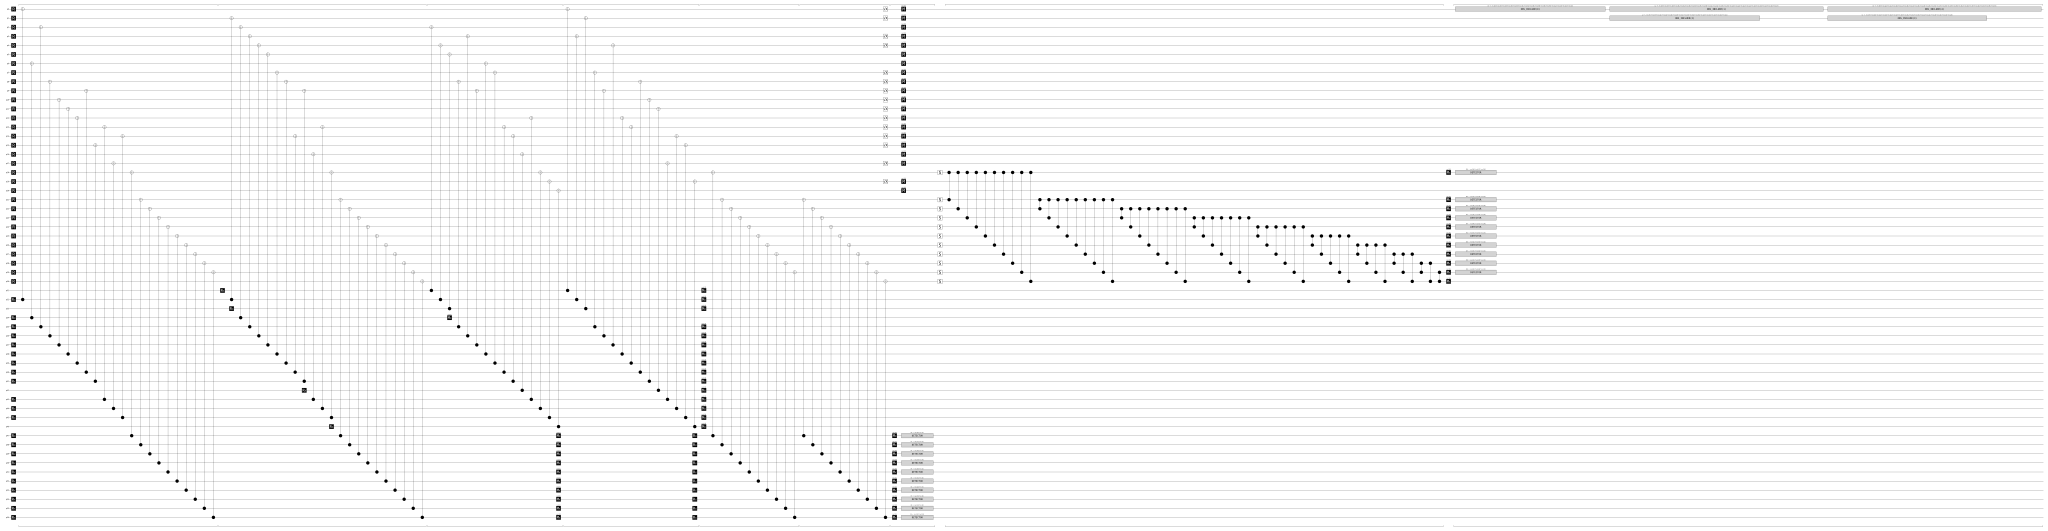

In [8]:
CreateCircuit(rounds = 1)[0].diagram('timeline-svg')

# Add noise

In [9]:
def AddNoise(circuit,p):

    # circuit with noise to be added
    result = stim.Circuit()

    # qubit acted on by gates in current timestep
    qubit_processed = []
    
    for instruction_index,instruction in enumerate(circuit):
                
        # preparation
        if instruction.name == 'RX':
            result.append(instruction)
            result.append("Z_ERROR",[target.qubit_value for target in instruction.targets_copy()],p)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

        # measurement
        elif instruction.name == 'MX':
            result.append("Z_ERROR",[target.qubit_value for target in instruction.targets_copy()],p)
            result.append(instruction)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

        # CNOT
        elif instruction.name == 'CX':
            result.append("PAULI_CHANNEL_2",instruction.targets_copy(),[0,0,p/3,0,0,0,0,0,0,0,0,p/3,0,0,p/3])
            result.append(instruction)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]
                
        # X^1/2
        elif instruction.name == 'SQRT_X':
            result.append(instruction)
            result.append("DEPOLARIZE1",[target.qubit_value for target in instruction.targets_copy()],p)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

        # add idle noise on unacted qubits
        elif instruction.name == 'TICK':
            for i in range(circuit.num_qubits):
                if i not in qubit_processed:
                    result.append("Z_ERROR",i,p)
            result.append(instruction)
            qubit_processed = []
            
        else:
            result.append(instruction)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

    circuit = result
    
    return circuit 

# Simulation

In [10]:
# create circuit
rounds = 600
circuit,detector_order = CreateCircuit(rounds = rounds)
circuit = AddNoise(circuit,5e-3)

# sample circuit
sampler = circuit.compile_detector_sampler()
batch_size = 5_000
detection_events, observables = sampler.sample(batch_size, separate_observables=True)

In [11]:
# remove first random round from detector order
for sublist in detector_order:
    removed_element = sublist[0]
    sublist.remove(removed_element)

    # reduce numbers higher by 1
    for i in range(len(detector_order)):
        for j in range(len(detector_order[i])):
            if detector_order[i][j]>removed_element:
                detector_order[i][j] -= 1

# Plot mean rounds (with min number of rounds = 5)

In [12]:
# start preselection only if at least *min_rounds* have been performed
min_rounds = 6

## Example: preselection = 3

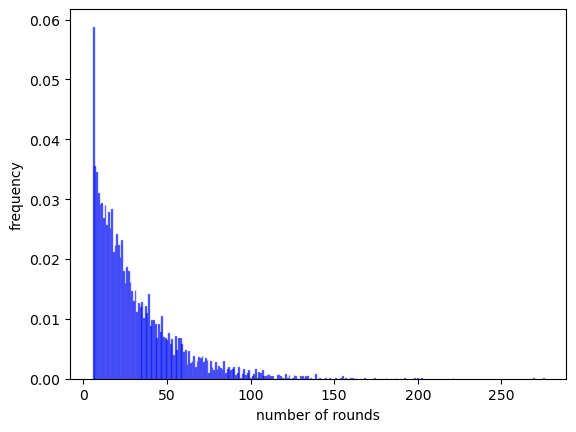

In [13]:
# number of rounds of preselection
preselection = 3

# store for all sample and all rounds 
# if the last *preselection* rounds are trivial
is_preselected = np.zeros((batch_size,rounds-preselection),dtype = bool)
for i in range(rounds-preselection):
    preselected_detectors = np.array(detector_order[:-len(out_qubits)+1])[:,i:i+preselection].flatten()
    is_preselected[:,i] = np.all(detection_events[:,preselected_detectors] == False,axis = 1)
    
# check that are enough total rounds for preselection
assert np.all(is_preselected[:,max(min_rounds-(1+preselection),0):].any(axis=1)), "Increase the number of rounds"
    
# check first round where preselection condition is met
first_preselect = np.argmax(is_preselected[:,max(min_rounds-(1+preselection),0):], axis=1) + max(min_rounds,preselection+1)

# compute frequency
counter = Counter(first_preselect)
keys = np.array(list(counter.keys()))
values = np.array(list(counter.values()))/batch_size

# sort keys
sorted_indices = np.argsort(keys)
# Apply the sorted indices
keys = keys[sorted_indices]
values = values[sorted_indices]

# Plot histogram
plt.bar(keys, values, width=0.5, edgecolor="blue", alpha=0.6)
plt.xlabel("number of rounds")
plt.ylabel("frequency")
plt.show()

In [14]:
mean = sum(keys*values)
print(f'mean rounds {mean}')
estimated_variance = np.sum((first_preselect-mean)**2)/batch_size
error_bar = np.sqrt(estimated_variance/batch_size)
print(f'error_bar {error_bar}')

mean rounds 30.5254
error_bar 0.35845149039723634


## Plot for various preselection

In [15]:
# number of preselection rounds
preselection_range = range(5)

# initialize with no preselection
mean_number_rounds = [min_rounds]
min_number_rounds = [min_rounds]
max_number_rounds = [min_rounds]

In [16]:
for preselection in preselection_range[1:]:
    print(f"{preselection}/{len(preselection_range)-1}",end = '\r')

    # store for all sample and all rounds 
    # if the last *preselection* rounds are trivial
    is_preselected = np.zeros((batch_size,rounds-preselection),dtype = bool)
    for i in range(rounds-preselection):
        preselected_detectors = np.array(detector_order[:-len(out_qubits)+1])[:,i:i+preselection].flatten()
        is_preselected[:,i] = np.all(detection_events[:,preselected_detectors] == False,axis = 1)
    
    # check that are enough total rounds for preselection
    assert np.all(is_preselected[:,max(min_rounds-(1+preselection),0):].any(axis=1))
    
    # check first round where preselection condition is met
    first_preselect = np.argmax(is_preselected[:,max(min_rounds-(1+preselection),0):], axis=1) + max(min_rounds,preselection+1)

    # compute frequency
    counter = Counter(first_preselect)
    keys = np.array(list(counter.keys()))
    values = np.array(list(counter.values()))/batch_size

    # mean number of rounds
    mean = np.sum(keys*values)
    mean_number_rounds.append(mean)
    
    # error bar
    estimated_variance = np.sum((first_preselect-mean)**2)/batch_size
    error_bar = np.sqrt(estimated_variance/batch_size)    
    min_number_rounds.append(mean - 1.96*error_bar)
    max_number_rounds.append(mean + 1.96*error_bar)

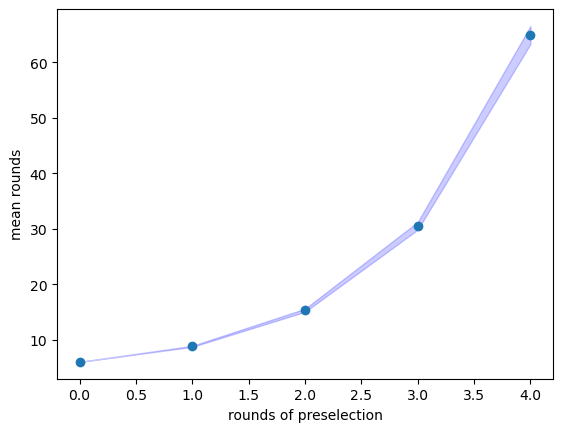

In [17]:
# mean number of rounds
plt.plot(preselection_range, mean_number_rounds, 'o')
# error bar
plt.fill_between(preselection_range, min_number_rounds, max_number_rounds, color='blue', alpha=0.2)

plt.ylabel('mean rounds')
plt.xlabel('rounds of preselection')
plt.show()

## Include distillation acceptance

In [18]:
# number of jobs
job_number = 100

# list of rounds
rounds_list = range(1,11)

# Store acceptance
Acceptance = np.full((len(preselection_range),len(rounds_list)),np.nan)
# Store acceptance uncertainty
Acceptance_u = np.full((len(preselection_range),len(rounds_list)),np.nan)

# loop on number of preselection rounds
for preselect in preselection_range:
    print(f"{preselect}/{len(preselection_range)-1}",end='\r')
    # loop on number of rounds
    for index_rounds, r in enumerate(rounds_list):
        nb_accepted = 0
        nb_preselected = 0
        # loop on number of jobs on the cluster
        for index in range(job_number):
            result = json.load(open(f'./Results//result_{r}_{index}.json', 'r'))

            if preselect < len(result['preselected&accepted&fail']):
                nb_preselected += result['preselected'][preselect]
                nb_accepted += result['preselected&accepted'][preselect]

        if nb_accepted != 0:
            Acceptance[preselect,index_rounds] = nb_accepted/nb_preselected
            Acceptance_u[preselect,index_rounds] = 1.96*np.sqrt(nb_accepted/nb_preselected**2*(1-nb_accepted/nb_preselected))

In [23]:
print("Acceptance")

column_names = [f"{i} round(s)" for i in range(1,11)]
row_names = [f"preselection {i} round(s)" for i in range(5)]
df = pd.DataFrame(Acceptance, columns=column_names, index=row_names)
df

Acceptance


,1 round(s),2 round(s),3 round(s),4 round(s),5 round(s),6 round(s),7 round(s),8 round(s),9 round(s),10 round(s)
preselection 0 round(s),0.645957,0.659778,0.733495,0.747539,0.754973,0.756702,0.757742,0.757741,0.758112,0.757903
preselection 1 round(s),NaN,0.853782,0.853725,0.853452,0.854762,0.854926,0.855147,0.855042,0.855143,0.854994
preselection 2 round(s),NaN,NaN,0.859053,0.858855,0.858998,0.859021,0.859089,0.858995,0.859075,0.858879
preselection 3 round(s),NaN,NaN,NaN,0.858899,0.859153,0.859100,0.859143,0.859378,0.859151,0.858974
preselection 4 round(s),NaN,NaN,NaN,NaN,0.859201,0.859138,0.858927,0.859261,0.859067,0.859142


In [24]:
# update mean number of rounds
for i in range(len(mean_number_rounds)):
    mean_number_rounds[i] = mean_number_rounds[i]/Acceptance[i,max(min_rounds-1,i)]
    min_number_rounds[i] = min_number_rounds[i]/(Acceptance[i,max(min_rounds-1,i)]+Acceptance_u[i,max(min_rounds-1,i)])
    max_number_rounds[i] = max_number_rounds[i]/(Acceptance[i,max(min_rounds-1,i)]-Acceptance_u[i,max(min_rounds-1,i)])

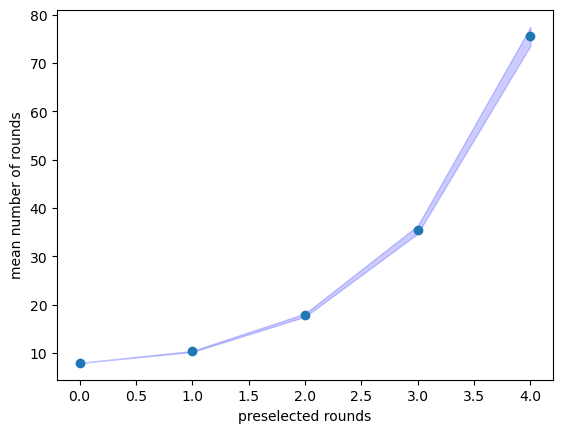

In [25]:
# mean number of rounds
plt.plot(preselection_range, mean_number_rounds, 'o')

# error bar
plt.fill_between(preselection_range, min_number_rounds, max_number_rounds,color = 'blue', alpha=0.2)

plt.xlabel('preselected rounds')
plt.ylabel('mean number of rounds')
plt.show()

# Mean rounds for every min number of rounds and preselection

In [26]:
# number of preselection rounds
preselection_range = range(4)

Mean_rounds_save = np.zeros((len(rounds_list),len(preselection_range)))

# start preselection only if at least *min_rounds* have been performed
for index,min_rounds in enumerate(rounds_list) :
    print(f"{min_rounds}/{len(rounds_list)}",end='\r')
    
    # initialize with no preselection
    mean_number_rounds = [min_rounds]
    
    ## preselection
    for preselection in preselection_range[1:]:

        # store for all sample and all rounds 
        # if the last *preselection* rounds are trivial
        is_preselected = np.zeros((batch_size,rounds-preselection),dtype = bool)
        for i in range(rounds-preselection):
            preselected_detectors = np.array(detector_order[:-len(out_qubits)+1])[:,i:i+preselection].flatten()
            is_preselected[:,i] = np.all(detection_events[:,preselected_detectors] == False,axis = 1)

        # check that are enough total rounds for preselection
        assert np.all(is_preselected[:,max(min_rounds-(1+preselection),0):].any(axis=1))

        # check first round where preselection condition is met
        first_preselect = np.argmax(is_preselected[:,max(min_rounds-(1+preselection),0):], axis=1) + max(min_rounds,preselection+1)

        # compute frequency
        counter = Counter(first_preselect)
        keys = np.array(list(counter.keys()))
        values = np.array(list(counter.values()))/batch_size

        # mean number of rounds
        mean_number_rounds.append(np.sum(keys*values))
   
    ## acceptance
    # update mean number of rounds
    for i in range(len(mean_number_rounds)):
        mean_number_rounds[i] = mean_number_rounds[i]/Acceptance[i,max(min_rounds-1,i)]
                                    
    Mean_rounds_save[index]=np.array(mean_number_rounds)

In [27]:
print("Mean number of rounds vs preselection and min rounds")

row_names = [f"min {i} round(s)" for i in range(1,11)]
column_names = [f"preselection {i} round(s)" for i in range(4)]
df = pd.DataFrame(Mean_rounds_save, columns=column_names, index=row_names)
df

Mean number of rounds vs preselection and min rounds


,preselection 0 round(s),preselection 1 round(s),preselection 2 round(s),preselection 3 round(s)
min 1 round(s),1.548092,5.639612,14.265701,33.348025
min 2 round(s),3.031322,5.639612,14.265701,33.348025
min 3 round(s),4.090007,6.804065,14.265701,33.348025
min 4 round(s),5.350889,7.974437,15.400508,33.348025
min 5 round(s),6.622751,9.161849,16.556272,34.519365
min 6 round(s),7.929145,10.304522,17.816551,35.531854
min 7 round(s),9.237979,11.433826,18.957055,36.566914
min 8 round(s),10.557701,12.613882,20.050178,37.640027
min 9 round(s),11.871600,13.777581,21.203034,38.807169
min 10 round(s),13.194299,14.979058,22.341693,39.979781


In [22]:
np.save('Mean_rounds.npy',Mean_rounds_save)